<a href="https://colab.research.google.com/github/ismailsohail15/Health-Risk-Classification-project/blob/main/open_ended.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
                          count        mean  ...        75%     max
Pregnancies               768.0    3.845052  ...    6.00000   17.00
Glucose                   768.0  121.677083  ...  140.25000  199.00
BloodPressure             768.0   72.389323  ...   80.00000  122.00
SkinThickness             768.0   29.089844  ...   32.00000   99.00
Insulin                   768.0  141.753906  ...  169.50000  846.00
BMI                       768.0   32.434635  ...   36.60000   67.10
DiabetesPedigreeFunction  768.0    0.471876  ...    0.62625    2.42
Age                       768.0   33.240885  ...   41.00000   81.00
Outcome                   768.0    0.348958  ...    1.00000    1.00

[9 rows x 8 columns]
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                 

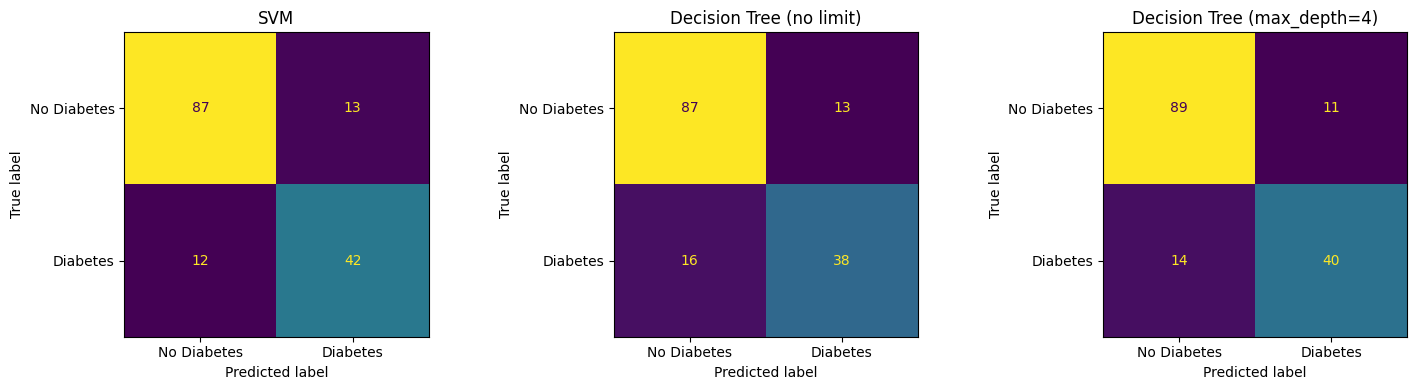

===== SVM =====
              precision    recall  f1-score   support

 No Diabetes       0.88      0.87      0.87       100
    Diabetes       0.76      0.78      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154

===== Decision Tree (no limit) =====
              precision    recall  f1-score   support

 No Diabetes       0.84      0.87      0.86       100
    Diabetes       0.75      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

===== Decision Tree (max_depth=4) =====
              precision    recall  f1-score   support

 No Diabetes       0.86      0.89      0.88       100
    Diabetes       0.78      0.74      0.76        54

    accuracy                           0.84       154
   macro avg       0.82      0.82  

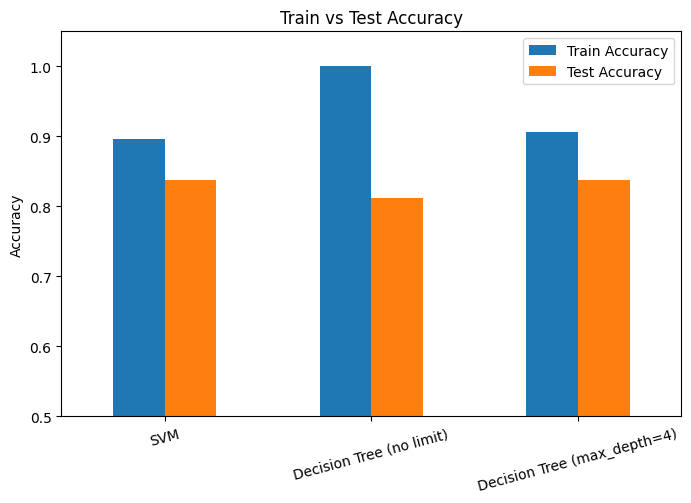

                               Gap
SVM                          0.058
Decision Tree (no limit)     0.188
Decision Tree (max_depth=4)  0.068


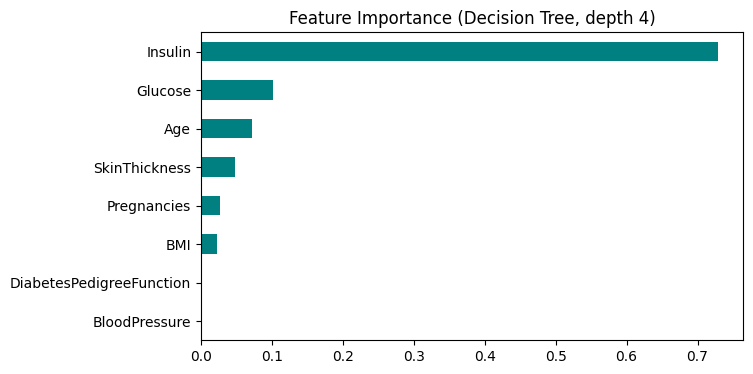

In [11]:
# Project: Health Risk Classification (Diabetes Prediction)
# Roll No: 24F-AI-042

# %% Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

# %% Cell 2: Load and describe the dataset
df = pd.read_csv("/kaggle/input/pima-indians-diabetes-dataset/diabetes.csv")

print("Shape:", df.shape)
print(df['Outcome'].value_counts())
print(df.describe().T)


# A person cannot have 0 glucose or 0 BMI, so these zeros are really missing values
cols_with_fake_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_fake_zero] = df[cols_with_fake_zero].replace(0, np.nan)
print(df.isnull().sum())

# %% Cell 4: Split, fill missing values, and scale
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split first, so test data does not leak into the median calculation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Fill missing values with the median (learned from train data only)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Normalize the numbers (SVM needs scaled data)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Train:", X_train_sc.shape, " Test:", X_test_sc.shape)

# %% Cell 5: Train the models
models = {
    "SVM": SVC(kernel='rbf', C=1.0, gamma='scale'),
    "Decision Tree (no limit)": DecisionTreeClassifier(random_state=42),
    "Decision Tree (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=42),
}

results = {}
preds = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    preds[name] = y_pred
    results[name] = {
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train_sc)),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    }

results_df = pd.DataFrame(results).T.round(3)
print(results_df)

# %% Cell 6: Confusion matrices and reports
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print("=====", name, "=====")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

# %% Cell 7: Overfitting check
results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(8, 5))
plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.05)
plt.xticks(rotation=15)
plt.show()

# A big gap between train and test accuracy means overfitting
results_df['Gap'] = results_df['Train Accuracy'] - results_df['Test Accuracy']
print(results_df[['Gap']])

# %% Cell 8: Feature importance (Decision Tree)
tree = models["Decision Tree (max_depth=4)"]
imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', color='teal', figsize=(7, 4))
plt.title("Feature Importance (Decision Tree, depth 4)")
plt.show()